In [1]:
include("dependencies.jl")
include("system_params.jl")
include("functions.jl")

f (generic function with 1 method)

In [2]:
total_qubits

3

In [3]:
typeof(H)

LazySum{CompositeBasis{Vector{Int64}, NTuple{4, NLevelBasis{Int64}}}, CompositeBasis{Vector{Int64}, NTuple{4, NLevelBasis{Int64}}}, Vector{ComplexF64}, Vector{Operator{CompositeBasis{Vector{Int64}, NTuple{4, NLevelBasis{Int64}}}, CompositeBasis{Vector{Int64}, NTuple{4, NLevelBasis{Int64}}}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}}}}

In [4]:
H_sparse = sparse(H)
typeof(H_sparse)

Operator{CompositeBasis{Vector{Int64}, NTuple{4, NLevelBasis{Int64}}}, CompositeBasis{Vector{Int64}, NTuple{4, NLevelBasis{Int64}}}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}}

In [6]:
N_trajectories = 1

basis = NLevelBasis(2)
k = transition(basis,2,2)
n_a = full_operator(k,total_qubits, [1])
n_c = full_operator(k, total_qubits, [3])
n_ac = full_operator(k, total_qubits, [1,3])


ψ0 = initialize_system()
println("The system has been initialized.")
# p1 = qubit_parameters(Ω, γ_Decay, γ_dephase, V_nn, δ)
tspan = [0.0:1:T_optimal;]

full_basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)


population_a = zeros(length(tspan))
population_c = zeros(length(tspan))
population_ac = zeros(length(tspan))

println("Starting the simulation...")
flush(stdout)
for i in 1:N_trajectories
    ψ0_ket = Ket(full_basis, ComplexF64.(ψ0)) 
    @time tout, ψt = timeevolution.mcwf_dynamic(tspan,ψ0_ket,f;alg=Rodas3(autodiff=false),maxiters=1e7);
    println("Trajectory $i")
    population_a[i] = real(expect(n_a, ψt))
    population_c[i] =  real(expect(n_c, ψt))
    population_ac[i] = real(expect(n_ac, ψt))
end

population_a ./= N_trajectories
population_c ./= N_trajectories
population_ac ./= N_trajectories


println("Simulation complete. Saving data...")

The system has been initialized.
Starting the simulation...


InterruptException: InterruptException:

In [21]:
pop = zeros(length(tspan))
ψ0_ket = Ket(full_basis, ComplexF64.(ψ0))
pop[1] = real(expect(n_a,ψ0_ket))

0.0

In [3]:
ψ0 = initialize_system()
# p1 = qubit_parameters(Ω, γ_Decay, γ_dephase, V_nn, δ)
tspan = [0.0:1:T_optimal;]
basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
ψ0_ket = Ket(basis, ComplexF64.(ψ0));

In [4]:
tout, ψt = timeevolution.mcwf_dynamic(tspan,ψ0_ket,f;alg=QNDF(autodiff=false));

In [15]:
n = 1 # Example: Number of elements
ψ_array = Vector{Vector{Ket{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}, NLevelBasis{Int64}}}, Vector{ComplexF64}}}}(undef, n)

ψ_array[1] = ψt;

In [17]:
ψ_array[1][2]

Ket(dim=8)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
                  0.0 + 0.0im
                  0.0 + 0.0im
   0.9978917543421523 + 0.06196008352777407im
  -0.0025365635062257 - 0.01341811406963786im
                  0.0 + 0.0im
                  0.0 + 0.0im
  -0.0025365635062257 - 0.01341811406963786im
 -0.00016883260053187 + 7.925599008336e-5im

In [22]:
expect(n_a,ψt)

155-element Vector{ComplexF64}:
                    0.0 + 0.0im
 0.00018651472556589603 + 0.0im
 0.00020877668870141895 + 0.0im
   6.232846706899774e-6 + 0.0im
  0.0005431563057971004 + 0.0im
   0.002885327802571773 + 0.0im
   0.003986164921675791 + 0.0im
 0.00039930432047204225 + 0.0im
   0.002793856749161648 + 0.0im
   0.002126183324743821 + 0.0im
                        ⋮
     0.9996688525688132 + 0.0im
       0.99761364551465 + 0.0im
     0.9960170864956653 + 0.0im
     0.9984692365303885 + 0.0im
     0.9999030445031896 + 0.0im
     0.9999171165086825 + 0.0im
     0.9997924655644718 + 0.0im
     0.9999518261587935 + 0.0im
     0.9998223827629273 + 0.0im

In [20]:
ρ = dm(ψ_array[1][2]/norm(ψ_array[1][2]))
typeof(ρ)

Operator{CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}, NLevelBasis{Int64}}}, CompositeBasis{Vector{Int64}, Tuple{NLevelBasis{Int64}, NLevelBasis{Int64}, NLevelBasis{Int64}}}, Matrix{ComplexF64}}

In [9]:
basis = NLevelBasis(2)
k = transition(basis,2,2)

n_a = full_operator(k,total_qubits, [1])
n_c = full_operator(k, total_qubits, [3])
n_ac = full_operator(k, total_qubits, [1,3])

pop_a = real(expect(n_a, ψt))
pop_c = real(expect(n_c, ψt));

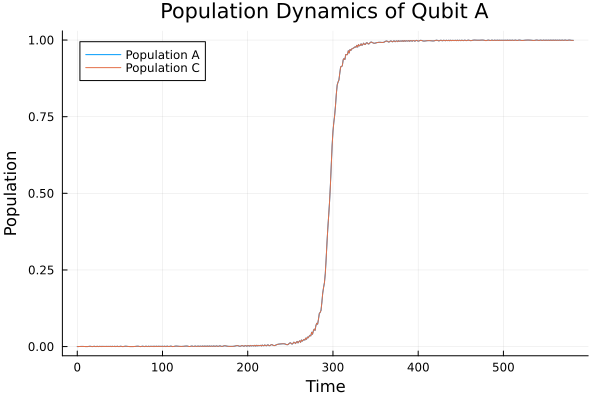

In [10]:
using Plots
plot(tout, pop_a, label="Population A", xlabel="Time", ylabel="Population", title="Population Dynamics of Qubit A")
plot!(tout, pop_c, label="Population C")

In [20]:
N_trajectories = 1
pop_a = zeros(length(tspan))
pop_c = zeros(length(tspan))

for i in 1:N_trajectories
    tout, ψt = timeevolution.mcwf_dynamic(tspan,ψ0_ket,f;alg=Rodas3(autodiff=false))
    pop_a .+= real(expect(n_a, ψt))
    pop_c .+= real(expect(n_c, ψt))
end

pop_a ./= N_trajectories
pop_c ./= N_trajectories

583-element Vector{Float64}:
 0.0
 7.105837437736182e-5
 0.00021876685268868972
 0.0003667640389568667
 0.00047594103132587236
 0.0005336978383097237
 0.0005382597322884288
 0.0004891866299343577
 0.0003868722423964444
 0.00024129136798591708
 ⋮
 0.9991032784320204
 0.9989856879233356
 0.9995539446138214
 0.9999817586959536
 0.9998497050155188
 0.9994032787812173
 0.9990410778828194
 0.9989407671433336
 0.9990553791725321

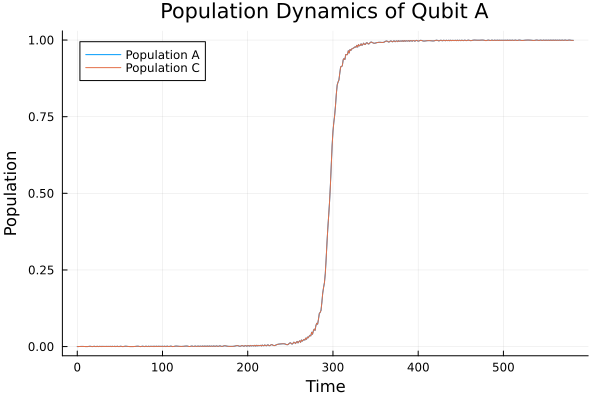

In [24]:
plot(tspan, pop_a, label="Population A", xlabel="Time", ylabel="Population", title="Population Dynamics of Qubit A")
plot!(tspan, pop_c, label="Population C")